<a href="https://colab.research.google.com/github/RithwikRajSuram/Predictive-Modeling-of-Chronic-Kidney-Disease/blob/main/Chronic_Kidney_Disease_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# -----------------------------
# Chronic Kidney Disease Project
# Logistic Regression & Linear Regression + ROC Curve
# -----------------------------

# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

# 2. Load dataset
df = pd.read_csv("kidney_disease_train.csv")

# 3. Data cleaning
# Convert numeric columns
num_cols = ["age", "bp", "sc"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Standardize target column
df["classification"] = df["classification"].astype(str).str.strip().str.lower()
df["target"] = df["classification"].map({"ckd": 1, "notckd": 0})

# Drop missing target values
df = df.dropna(subset=["target"])

# -----------------------------
# Logistic Regression (Classification)
# -----------------------------
# Select features
X = df[["age", "bp", "sc"]].dropna()
y = df.loc[X.index, "target"]

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Predictions
y_pred = log_model.predict(X_val)
y_pred_prob = log_model.predict_proba(X_val)[:,1]

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[18  4]
 [ 5 25]]


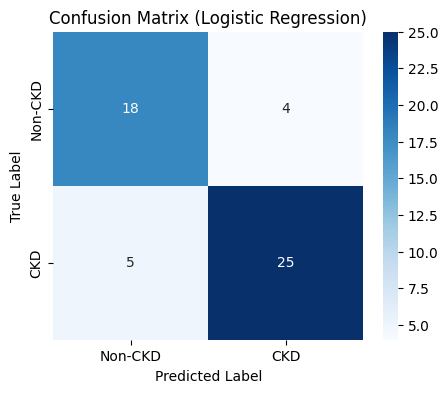

In [5]:
# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-CKD","CKD"], yticklabels=["Non-CKD","CKD"])
plt.title("Confusion Matrix (Logistic Regression)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

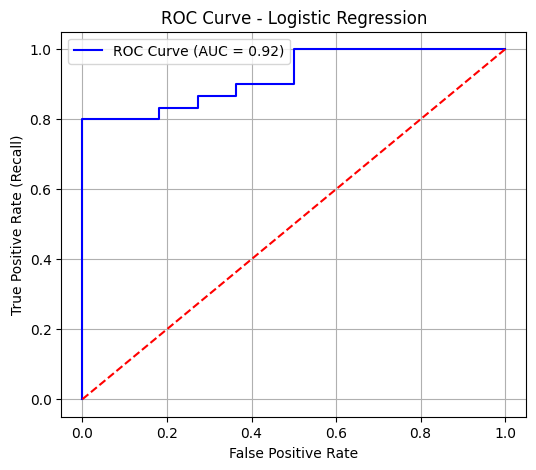

In [6]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob)
auc = roc_auc_score(y_val, y_pred_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="blue", label=f"ROC Curve (AUC = {auc:.2f})")
plt.plot([0,1], [0,1], color="red", linestyle="--")  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
# -----------------------------
# Linear Regression (bp vs sc)
# -----------------------------
# Take only bp (X) and sc (y)
pair = df[["bp","sc"]].dropna()
X_bp = pair["bp"].values.reshape(-1,1)
y_sc = pair["sc"].values

# Fit regression model
lin_model = LinearRegression()
lin_model.fit(X_bp, y_sc)

# Coefficients
a = lin_model.coef_[0]
b = lin_model.intercept_
print(f"\nLinear Regression Equation: sc = {a:.4f} × bp + {b:.4f}")


Linear Regression Equation: sc = 0.0677 × bp + -2.0970


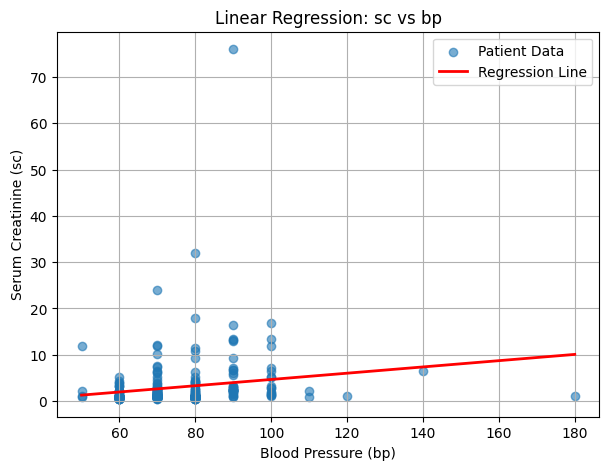

In [8]:
# Regression line
x_range = np.linspace(X_bp.min(), X_bp.max(), 100).reshape(-1,1)
y_pred_line = lin_model.predict(x_range)

# Plot scatter + regression line
plt.figure(figsize=(7,5))
plt.scatter(X_bp, y_sc, alpha=0.6, label="Patient Data")
plt.plot(x_range, y_pred_line, color="red", linewidth=2, label="Regression Line")
plt.xlabel("Blood Pressure (bp)")
plt.ylabel("Serum Creatinine (sc)")
plt.title("Linear Regression: sc vs bp")
plt.legend()
plt.grid(True)
plt.show()